# IND320 Assignment 1

Niclas

GitHub repository: https://github.com/karlsenniclas-ops/IND320-Assignment

Streamlit app: https://ind320-assignment-1.streamlit.app/plot

## Log

For this assignment I worked with the reservoirs.csv dataset from the course data folder. It contains weekly NVE reservoir statistics for Norway, going back to 1995. I created a public GitHub repo and deploy the Streamlit app through share.streamlit.io, with app.py as the main file.

The raw column names were in Norwegian, so I renamed them to English, for example fyllingsgrad became fill_level and kapasitet_TWh became capacity_twh.

I found that the rows are not sorted by date, and that the file has 9 different areas: all of Norway (omrType = NO), five price areas (EL 1-5) and three watercourse areas (VASS 1-3), one row per week each. Since I only need one time series, I filtered to omrType == "NO" and sorted by date.

The fill level and stored energy follow a clear yearly pattern, lowest in April and May and highest from September to November, with the biggest weekly increases in May and June from snowmelt. Capacity is a flat line, since it does not change from week to week.

Plotting all five columns together was harder, because fill_level, fill_level_prev_week and fill_level_change are shares between roughly -0.15 and 1, while capacity_twh and stored_energy_twh are in TWh and go up to around 87. I solved this with a second y-axis, left for shares and right for TWh. I put the share columns first in the DataFrame, otherwise pandas gave the same colours to columns on different axes, and I built the legend manually so it sits below the plot instead of covering the lines.

The Streamlit app follows the same structure. app.py uses st.navigation to list the page files (home, table, plot, page4) as a sidebar menu. data.py has one function, load_data, with st.cache_data so the CSV is only read once per session. The table page uses st.column_config.LineChartColumn to show the first month of each column as a small chart. The plot page has a selectbox for one column or all of them, and a select_slider for the month range, defaulting to the first month.

## AI usage

I used Claude Opus 4.8 to help debug and write some of the code for the Streamlit app (helped write some of the features in plot.py). I ran all cells myself, checked that the output and plots looked correct, and tested the app before handing it in.

## Imports

In [1]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt

## Read the data

In [2]:
# Read the raw CSV file
df = pd.read_csv("reservoirs.csv")
df.head()

,dato_Id,omrType,omrnr,iso_aar,iso_uke,fyllingsgrad,kapasitet_TWh,fylling_TWh,neste_Publiseringsdato,fyllingsgrad_forrige_uke,endring_fyllingsgrad
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301


## Rename headers

In [3]:
# Norwegian to English column names
rename_map = {
    "dato_Id": "date",
    "omrType": "area_type",
    "omrnr": "area_number",
    "iso_aar": "iso_year",
    "iso_uke": "iso_week",
    "fyllingsgrad": "fill_level",
    "kapasitet_TWh": "capacity_twh",
    "fylling_TWh": "stored_energy_twh",
    "neste_Publiseringsdato": "next_publication_date",
    "fyllingsgrad_forrige_uke": "fill_level_prev_week",
    "endring_fyllingsgrad": "fill_level_change",
}
df = df.rename(columns=rename_map)

# Convert date column to datetime
df["date"] = pd.to_datetime(df["date"])
df.head()

,date,area_type,area_number,iso_year,iso_week,fill_level,capacity_twh,stored_energy_twh,next_publication_date,fill_level_prev_week,fill_level_change
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301


## Explore the data

In [4]:
# Overview of the dataframe: columns, dtypes and missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14877 entries, 0 to 14876
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   date                   14877 non-null  datetime64[us]
 1   area_type              14877 non-null  str           
 2   area_number            14877 non-null  int64         
 3   iso_year               14877 non-null  int64         
 4   iso_week               14877 non-null  int64         
 5   fill_level             14877 non-null  float64       
 6   capacity_twh           14877 non-null  float64       
 7   stored_energy_twh      14877 non-null  float64       
 8   next_publication_date  14877 non-null  str           
 9   fill_level_prev_week   14877 non-null  float64       
 10  fill_level_change      14877 non-null  float64       
dtypes: datetime64[us](1), float64(5), int64(3), str(2)
memory usage: 1.6 MB


In [5]:
# Number of rows per area type and area number
df[["area_type", "area_number"]].value_counts().sort_index()

area_type  area_number
EL         1              1653
           2              1653
           3              1653
           4              1653
           5              1653
NO         0              1653
VASS       1              1653
           2              1653
           3              1653
Name: count, dtype: int64

In [6]:
# First and last date in the data
print("First date:", df["date"].min())
print("Last date:", df["date"].max())

First date: 1995-01-08 00:00:00
Last date: 2026-09-06 00:00:00


In [7]:
# Summary statistics for the five value columns
value_columns = ["fill_level", "capacity_twh", "stored_energy_twh", "fill_level_prev_week", "fill_level_change"]
df[value_columns].describe()

,fill_level,capacity_twh,stored_energy_twh,fill_level_prev_week,fill_level_change
count,14877.000000,14877.000000,14877.000000,14877.000000,14877.000000
mean,0.618852,29.145860,18.139713,0.618890,-0.000038
std,0.214850,22.739070,15.966211,0.214843,0.031385
min,0.055160,6.003264,0.331142,0.055160,-0.242484
25%,0.456234,17.390587,7.321973,0.456356,-0.022395
50%,0.648049,23.237715,14.501389,0.648114,-0.007072
75%,0.802135,34.043590,22.203530,0.802133,0.016277
max,1.020072,87.437580,84.544820,1.020037,0.336623


In [8]:
# Keep only rows for all of Norway, sort by date and use date as index
norway = df[df["area_type"] == "NO"].sort_values("date").set_index("date")
norway = norway[value_columns]
norway.head()

,fill_level,capacity_twh,stored_energy_twh,fill_level_prev_week,fill_level_change
date,,,,,
1995-01-08,0.608274,87.43758,53.185986,0.752703,-0.144430
1995-01-15,0.582372,87.43758,50.921207,0.608274,-0.025902
1995-01-22,0.562412,87.43758,49.175980,0.582390,-0.019977
1995-01-29,0.534508,87.43758,46.736122,0.562412,-0.027904
1995-02-05,0.506486,87.43758,44.285900,0.534489,-0.028003


## Plot each column separately

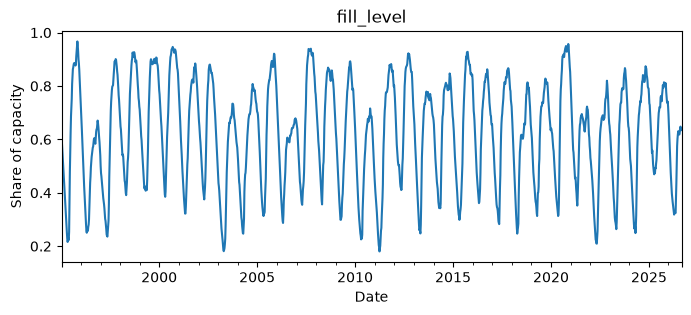

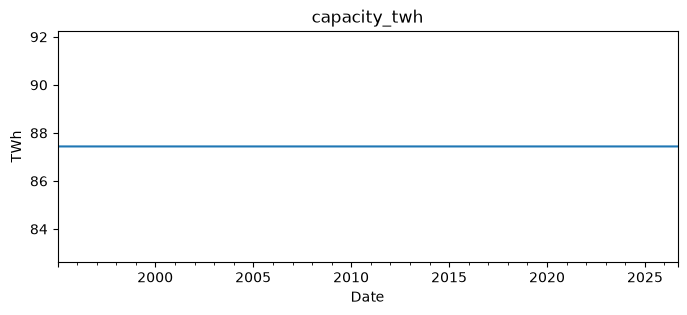

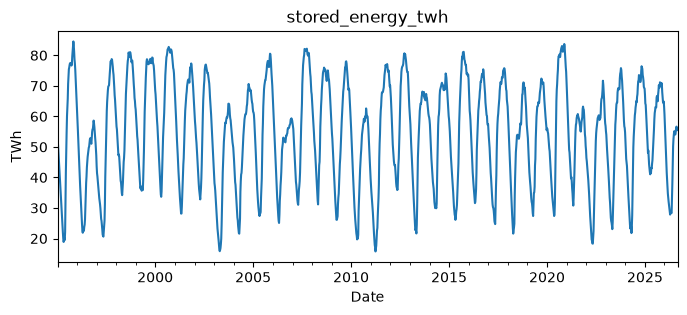

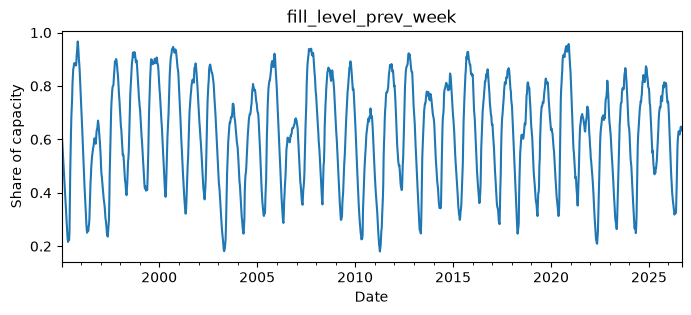

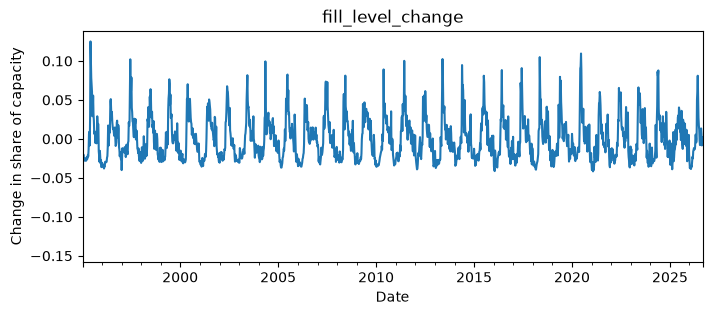

In [9]:
# Units for each column, used as y-axis labels
units = {
    "fill_level": "Share of capacity",
    "capacity_twh": "TWh",
    "stored_energy_twh": "TWh",
    "fill_level_prev_week": "Share of capacity",
    "fill_level_change": "Change in share of capacity",
}

# One plot per column, new figure each time so they don't overlap
for col in norway.columns:
    fig, ax = plt.subplots(figsize=(8, 3))
    norway[col].plot(ax=ax, title=col)
    ax.set_xlabel("Date")
    ax.set_ylabel(units[col])
    plt.show()

## Plot all columns together

The share columns (0 to 1) and the TWh columns (up to about 87) are on very different scales, so a second y-axis is needed, otherwise the TWh lines would flatten the share lines to nearly zero.

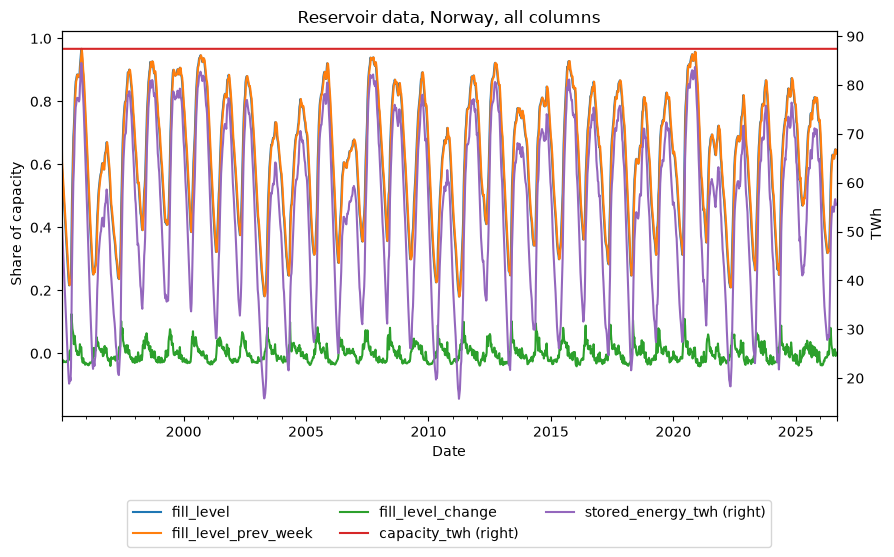

In [10]:
# Share columns first, TWh columns last: keeps the legend colours in sync with the left axis
plot_order = ["fill_level", "fill_level_prev_week", "fill_level_change", "capacity_twh", "stored_energy_twh"]
twh_columns = ["capacity_twh", "stored_energy_twh"]

fig, ax = plt.subplots(figsize=(10, 5))
norway[plot_order].plot(ax=ax, secondary_y=twh_columns)
ax.set_xlabel("Date")
ax.set_ylabel("Share of capacity")
ax.right_ax.set_ylabel("TWh")
ax.set_title("Reservoir data, Norway, all columns")

# Combine the legend from both axes and place it below the plot so it does not overlap with the graph
lines = ax.get_lines() + ax.right_ax.get_lines()
labels = [line.get_label() for line in lines]
ax.get_legend().remove()
ax.legend(lines, labels, loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=3)

plt.show()